# Life Quality Predictor - Pipeline Training

This notebook trains a Random Forest model with a scikit-learn Pipeline and generates a ydata-profiling report.

In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Setup completed successfully.")

Setup completed successfully.


In [38]:

csv_path = 'dataset.csv'
if not os.path.exists(csv_path):
    csv_path = '../dataset.csv'

data = pd.read_csv(csv_path)
print(f"Loaded dataset with shape: {data.shape}")
print(data.head())

Loaded dataset with shape: (20, 18)
        city  latitude  longitude  population  population_density    aqi  \
0    Kolkata   22.5726    88.3639   4496694.0                 NaN  143.0   
1      Delhi   28.6139    77.2090  26495000.0                 NaN   92.0   
2     Mumbai   19.0760    72.8777  15414288.0                 NaN   60.0   
3  Bangalore   12.9716    77.5946         NaN                 NaN    NaN   
4    Chennai   13.0827    80.2707   6599000.0                 NaN   82.0   

   temperature  humidity  crime_rate  hospital_density  school_density  \
0         29.5        86     16041.0             416.0             NaN   
1         33.4        48     15100.0               NaN             NaN   
2         26.2        93     56435.0            1308.0             NaN   
3         22.4        83     19365.0               NaN             NaN   
4         27.9        86     11815.0             552.0             NaN   

   internet_score  employment_rate  green_cover  cost_of_livin

In [39]:

target_col = 'livability_score'
numeric_features = [
    'aqi', 'temperature', 'humidity', 'green_cover', 
    'hospital_density', 'school_density', 'internet_score', 
    'population_density', 'crime_rate', 
    'employment_rate', 'cost_of_living'
]
nominal_features = ['climate_zone']
ordinal_features = ['development_tier']

num_cols = [c for c in numeric_features if c in data.columns]
nom_cols = [c for c in nominal_features if c in data.columns]
ord_cols = [c for c in ordinal_features if c in data.columns]

data_clean = data.dropna(subset=[target_col])
X = data_clean[num_cols + nom_cols + ord_cols]
y = data_clean[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [40]:


num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('knn_imputer', KNNImputer(n_neighbors=3)),
    ('scaler', StandardScaler())
])

nom_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['Tier 3', 'Tier 2', 'Tier 1']], handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('nom', nom_transformer, nom_cols),
    ('ord', ord_transformer, ord_cols)
])


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42))
])

print("Pipeline constructed successfully.")

Pipeline constructed successfully.


In [41]:

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test R2: {r2:.4f}")

Test MSE: 100.2356
Test R2: -1.7814


c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['green_cover' 'population_density']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['green_cover' 'population_density']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [42]:

importances = pipeline.named_steps['regressor'].feature_importances_
feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()



In [43]:

cleaned_feature_names = []
for name in feature_names_out:
    cleaned_name = name
    for prefix in ['num__', 'nom__', 'ord__']:
        if cleaned_name.startswith(prefix):
            cleaned_name = cleaned_name[len(prefix):]
            break
    cleaned_feature_names.append(cleaned_name)

feature_importances = pd.Series(importances, index=cleaned_feature_names).sort_values(ascending=True)

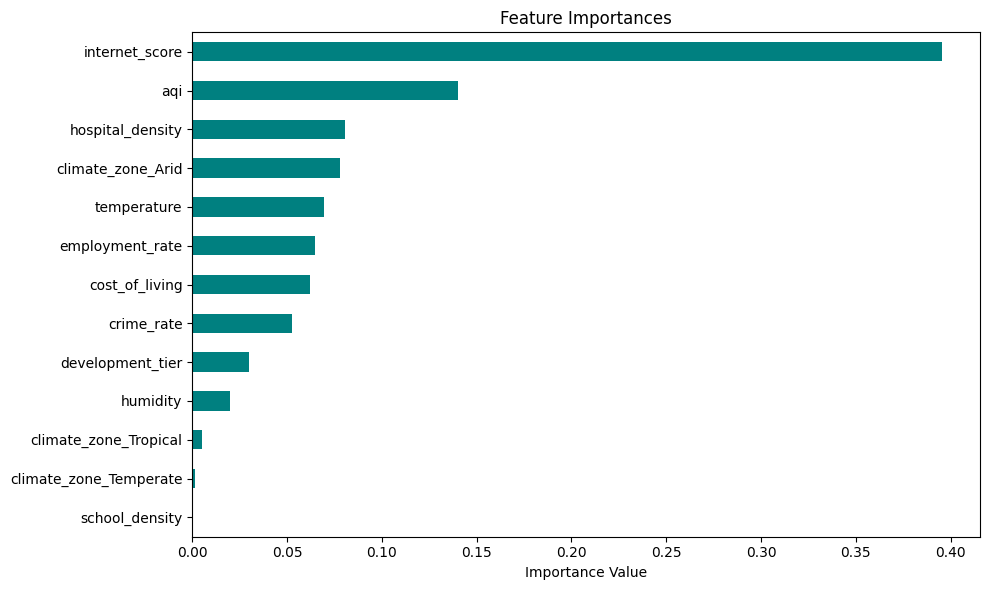

In [44]:


plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='teal')
plt.title('Feature Importances')
plt.xlabel('Importance Value')
plt.tight_layout()
plt.show()

In [45]:


pipeline.fit(X, y)


c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['green_cover' 'population_density']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [46]:
y_full_pred = pipeline.predict(X)
full_mse = mean_squared_error(y, y_full_pred)
full_r2 = r2_score(y, y_full_pred)


c:\Users\shuva\anaconda3\envs\shuvam1\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['green_cover' 'population_density']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [47]:

feature_importances_dict = {name: float(imp) for name, imp in zip(cleaned_feature_names, importances)}
feature_importances_dict = dict(sorted(feature_importances_dict.items(), key=lambda item: item[1], reverse=True))

bundle = {
    "pipeline": pipeline,
    "feature_names": num_cols + nom_cols + ord_cols,
    "metrics": {
        "mse": float(full_mse),
        "r2": float(full_r2),
        "samples_count": len(y)
    },
    "feature_importances": feature_importances_dict
}



In [48]:
joblib.dump(bundle, '../livability_model.pkl')
print("Model bundle persisted to '../livability_model.pkl'")

Model bundle persisted to '../livability_model.pkl'
